In [1]:
from pecos.qeclib.color488 import Color488Patch

In [2]:
from pecos.slr import Main, SlrConverter, CReg

distance = 7

prog = Main(
    
    c := Color488Patch("c", distance, num_ancillas=4),  # << Logical qubit
    
    syn1 := CReg("syn1", c.num_data - 1),
    syn2 := CReg("syn2", c.num_data - 1),
    
    c.syn_extract_bare(syn1),
    c.syn_extract_bare(syn2),
)

In [3]:
c.layout.get_layout()

({0: (12, 12),
  1: (14, 12),
  2: (12, 10),
  3: (14, 10),
  4: (8, 8),
  5: (10, 8),
  6: (16, 8),
  7: (18, 8),
  8: (8, 6),
  9: (10, 6),
  10: (16, 6),
  11: (18, 6),
  12: (4, 4),
  13: (6, 4),
  14: (12, 4),
  15: (14, 4),
  16: (20, 4),
  17: (22, 4),
  18: (4, 2),
  19: (6, 2),
  20: (12, 2),
  21: (14, 2),
  22: (20, 2),
  23: (22, 2),
  24: (0, 0),
  25: (2, 0),
  26: (8, 0),
  27: (10, 0),
  28: (16, 0),
  29: (18, 0),
  30: (24, 0)},
 [[4, 5, 2, 0, 'blue'],
  [0, 2, 3, 1, 'red'],
  [4, 8, 9, 5, 'red'],
  [2, 5, 9, 14, 15, 10, 6, 3, 'green'],
  [6, 10, 11, 7, 'red'],
  [7, 11, 16, 17, 'green'],
  [24, 25, 18, 12, 'blue'],
  [12, 18, 19, 13, 'red'],
  [8, 13, 19, 26, 27, 20, 14, 9, 'blue'],
  [14, 20, 21, 15, 'red'],
  [10, 15, 21, 28, 29, 22, 16, 11, 'blue'],
  [16, 22, 23, 17, 'red'],
  [18, 25, 26, 19, 'green'],
  [20, 27, 28, 21, 'green'],
  [22, 29, 30, 23, 'green']])

In [4]:
c.num_data

31

In [5]:
qasm = SlrConverter(prog, optimize_parallel=True).qasm()

In [6]:
print(qasm)

OPENQASM 2.0;
include "hqslib1.inc";
qreg c_d__[31];
qreg c_a__[4];
creg c_meas__[31];
creg syn1[30];
creg syn2[30];
// Check['Z', [4, 5, 2, 0]] -> syn1[0]
// Check['Z', [0, 2, 3, 1]] -> syn1[1]
// Check['Z', [4, 8, 9, 5]] -> syn1[2]
// Check['Z', [2, 5, 9, 14, 15, 10, 6, 3]] -> syn1[3]
// Check['Z', [6, 10, 11, 7]] -> syn1[4]
// Check['Z', [7, 11, 16, 17]] -> syn1[5]
// Check['Z', [24, 25, 18, 12]] -> syn1[6]
// Check['Z', [12, 18, 19, 13]] -> syn1[7]
// Check['Z', [8, 13, 19, 26, 27, 20, 14, 9]] -> syn1[8]
// Check['Z', [14, 20, 21, 15]] -> syn1[9]
// Check['Z', [10, 15, 21, 28, 29, 22, 16, 11]] -> syn1[10]
// Check['Z', [16, 22, 23, 17]] -> syn1[11]
// Check['Z', [18, 25, 26, 19]] -> syn1[12]
// Check['Z', [20, 27, 28, 21]] -> syn1[13]
// Check['Z', [22, 29, 30, 23]] -> syn1[14]
// Check['X', [4, 5, 2, 0]] -> syn1[15]
// Check['X', [0, 2, 3, 1]] -> syn1[16]
// Check['X', [4, 8, 9, 5]] -> syn1[17]
// Check['X', [2, 5, 9, 14, 15, 10, 6, 3]] -> syn1[18]
// Check['X', [6, 10, 11, 7]] ->

<module 'matplotlib.pyplot' from '/home/ciaranra/Repos/cl_projects/color/PECOS/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py'>

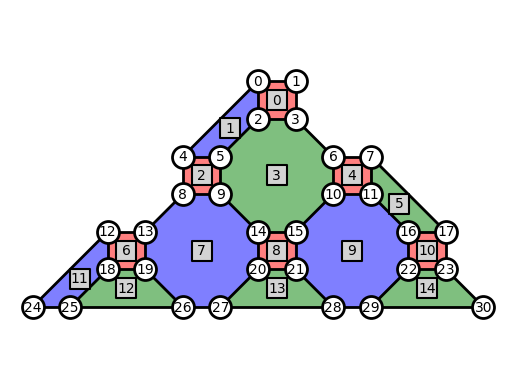

In [7]:
c.plot_layout(numbered_qubits=True, numbered_poly=True)

In [8]:
from pecos_rslib.qasm_sim import (
    qasm_sim,
    QuantumEngine,
    DepolarizingNoise,
)

In [9]:
from pecos.slr import Main, SlrConverter, CReg
from pecos.qeclib import qubit as qb

d = 5

prog = Main(
    
    c := Color488Patch("c", d, num_ancillas=4),  # << Logical qubit
    qb.X(c.d[1]), # inject error
        
    syn0 := CReg(f"syn0", c.num_data - 1),
    syn1 := CReg(f"syn1", c.num_data - 1),
    
    c.syn_extract_bare(syn0),
    c.syn_extract_bare(syn1),
)

qasm = SlrConverter(prog).qasm()

In [10]:
data = (
    qasm_sim(qasm)
        .quantum_engine(QuantumEngine.SparseStabilizer)
        .with_binary_string_format()
        .run(5)
)
data

{'c_meas__': ['00000000000000000',
  '00000000000000000',
  '00000000000000000',
  '00000000000000000',
  '00000000000000000'],
 'syn0': ['1100011000000011',
  '0110000000000011',
  '1110011000000011',
  '1110110000000011',
  '0111000100000011'],
 'syn1': ['1100011000000011',
  '0110000000000011',
  '1110011000000011',
  '1110110000000011',
  '0111000100000011']}

In [11]:
from pecos.slr import Main, SlrConverter, CReg
from pecos.qeclib import qubit as qb

d = 5

prog = Main(
    
    c := Color488Patch("a", d, num_ancillas=4),  # << Logical qubit
    # qb.X(a.d[1]),  # inject error
)

rounds = d
syns = []

for i in range(rounds):
    
    # if i == 1:
    #     prog.extend(qb.Y(a.d[1]))
        
    prog.extend(
        syn := CReg(f"syn{i}", c.num_data - 1),
        c.syn_extract_bare(syn),
    )

    syns.append(syn)

# Calculate syn diff in program
prog.extend(
    diff := CReg("diff", c.num_data - 1),
    diff.set(syns[0] ^ syns[1])
)

qasm = SlrConverter(prog).qasm()

In [12]:
from pecos_rslib.qasm_sim import (
    qasm_sim,
    QuantumEngine,
    DepolarizingNoise,
)

In [13]:
data = (
    qasm_sim(qasm)
        .quantum_engine(QuantumEngine.SparseStabilizer)
        .with_binary_string_format()
        .run(5)
)
data

{'a_meas__': ['00000000000000000',
  '00000000000000000',
  '00000000000000000',
  '00000000000000000',
  '00000000000000000'],
 'diff': ['0000000000000000',
  '0000000000000000',
  '0000000000000000',
  '0000000000000000',
  '0000000000000000'],
 'syn0': ['0010101000000000',
  '0110011000000000',
  '0011110000000000',
  '0111001000000000',
  '0101100000000000'],
 'syn1': ['0010101000000000',
  '0110011000000000',
  '0011110000000000',
  '0111001000000000',
  '0101100000000000'],
 'syn2': ['0010101000000000',
  '0110011000000000',
  '0011110000000000',
  '0111001000000000',
  '0101100000000000'],
 'syn3': ['0010101000000000',
  '0110011000000000',
  '0011110000000000',
  '0111001000000000',
  '0101100000000000'],
 'syn4': ['0010101000000000',
  '0110011000000000',
  '0011110000000000',
  '0111001000000000',
  '0101100000000000']}

In [14]:
from pecos.tools.syndromes import syn_diff

In [15]:
syn_diff(data, [("syn0", "syn1")])

{'syn0_syn1': ['0000000000000000',
  '0000000000000000',
  '0000000000000000',
  '0000000000000000',
  '0000000000000000']}

In [16]:
data = (
    qasm_sim(qasm)
        .with_binary_string_format()
        .noise(DepolarizingNoise(p=0.003))
        .run(5)
)
data

{'a_meas__': ['00000000000000000',
  '00000000000000000',
  '00000000000000000',
  '00000000000000000',
  '00000000000000000'],
 'diff': ['0001000000000000',
  '0000000000000001',
  '0000100000000000',
  '1000000000000000',
  '0000000000000000'],
 'syn0': ['0010000010110000',
  '1110101100000000',
  '0000111100000000',
  '0111010100000000',
  '0110111000000000'],
 'syn1': ['0011000010110000',
  '1110101100000001',
  '0000011100000000',
  '1111010100000000',
  '0110111000000000'],
 'syn2': ['0011000010110000',
  '1110101100000000',
  '0000111100000000',
  '1111010100000000',
  '0110001000000000'],
 'syn3': ['0011000010110000',
  '1110111100000000',
  '0000111100000000',
  '1111010100000000',
  '0010111001001100'],
 'syn4': ['0101000010110000',
  '1110110100000100',
  '0000111100000000',
  '0101010100100000',
  '0010111101101100']}

In [17]:
syn_diff(data, [("syn0", "syn1")])

{'syn0_syn1': ['0001000000000000',
  '0000000000000001',
  '0000100000000000',
  '1000000000000000',
  '0000000000000000']}

In [18]:
from pecos.qeclib.color488.meas.destructive_meas import MeasureZ, SynMeasProcessing

In [19]:
SynMeasProcessing

pecos.qeclib.color488.meas.destructive_meas.SynMeasProcessing

In [20]:
prog = Main(
    c := Color488Patch("c", distance=5, num_ancillas=4),
    meas := CReg("meas", c.num_data),
    syn_meas := CReg("syn_meas", c.num_data - 1),
    log := CReg("log", 1),
)

rounds = 3
syn_preps = [CReg(f"syn_prep_{i}", c.num_data - 1) for i in range(rounds)]

prog.extend(
    *syn_preps,
    c.prep_z_bare(syn_preps),
    # c.h(),
    c.meas_z(meas, syn=syn_meas, log=log),
)

qasm = SlrConverter(prog, optimize_parallel=False).qasm()

print(qasm)

num_data 17 distance 5
log_indices [12, 13, 14, 15, 16]
OPENQASM 2.0;
include "hqslib1.inc";
qreg c_d__[17];
qreg c_a__[4];
creg c_meas__[17];
creg meas[17];
creg syn_meas[16];
creg log[1];
creg syn_prep_0[16];
creg syn_prep_1[16];
creg syn_prep_2[16];
reset c_d__[0];
reset c_d__[1];
reset c_d__[2];
reset c_d__[3];
reset c_d__[4];
reset c_d__[5];
reset c_d__[6];
reset c_d__[7];
reset c_d__[8];
reset c_d__[9];
reset c_d__[10];
reset c_d__[11];
reset c_d__[12];
reset c_d__[13];
reset c_d__[14];
reset c_d__[15];
reset c_d__[16];
// Check['Z', [0, 2, 3, 1]] -> syn_prep_0[0]
// Check['Z', [1, 3, 6, 7]] -> syn_prep_0[1]
// Check['Z', [12, 13, 8, 4]] -> syn_prep_0[2]
// Check['Z', [4, 8, 9, 5]] -> syn_prep_0[3]
// Check['Z', [2, 5, 9, 14, 15, 10, 6, 3]] -> syn_prep_0[4]
// Check['Z', [6, 10, 11, 7]] -> syn_prep_0[5]
// Check['Z', [8, 13, 14, 9]] -> syn_prep_0[6]
// Check['Z', [10, 15, 16, 11]] -> syn_prep_0[7]
// Check['X', [0, 2, 3, 1]] -> syn_prep_0[8]
// Check['X', [1, 3, 6, 7]] -> syn_pre

In [21]:
nd = c.num_data
d = c.distance

for i in range (nd - d, nd):
    print(i)

12
13
14
15
16


In [22]:
data = (
    qasm_sim(qasm)
        .quantum_engine(QuantumEngine.SparseStabilizer)
        .with_binary_string_format()
        .run(5)
)
data

{'c_meas__': ['11110110000111111',
  '10100101010100110',
  '10111100010000110',
  '11011110111010101',
  '00000001111111010'],
 'log': ['0', '0', '0', '0', '0'],
 'meas': ['11110110000111111',
  '10100101010100110',
  '10111100010000110',
  '11011110111010101',
  '00000001111111010'],
 'syn_meas': ['0000000000000001',
  '0000000000000001',
  '0000000000000001',
  '0000000000000001',
  '0000000000000000'],
 'syn_prep_0': ['0110010000000000',
  '0100011000000000',
  '0001000000000000',
  '1110111000000000',
  '1111000000000000'],
 'syn_prep_1': ['0110010000000000',
  '0100011000000000',
  '0001000000000000',
  '1110111000000000',
  '1111000000000000'],
 'syn_prep_2': ['0110010000000000',
  '0100011000000000',
  '0001000000000000',
  '1110111000000000',
  '1111000000000000']}

In [23]:
from pecos.slr import Main, Block, QReg, CReg, Parallel
from pecos.qeclib import qubit as qb

prog = Main(                       
    q := QReg("q", 6),             
    c := CReg("m", 6),             
    Parallel(                      
        Block(  # Bell pair 1      
            qb.H(q[0]),            
            qb.CX(q[0], q[1]),     
        ),                         
        Block(  # Bell pair 2      
            qb.H(q[2]),            
            qb.CX(q[2], q[3]),     
        ),                         
        Block(  # Bell pair 3      
            qb.H(q[4]),            
            qb.CX(q[4], q[5]),     
        ),                         
    ),                             
    qb.Measure(q) > c,             
)                                  
qasm = SlrConverter(prog, optimize_parallel=False).qasm()
print(qasm)

OPENQASM 2.0;
include "hqslib1.inc";
qreg q[6];
creg m[6];
h q[0];
cx q[0], q[1];
h q[2];
cx q[2], q[3];
h q[4];
cx q[4], q[5];
measure q -> m;


In [24]:
from pecos.slr import Main, Block, QReg, CReg, Parallel
from pecos.qeclib import qubit as qb

prog = Main(                       
    q := QReg("q", 6),             
    c := CReg("m", 6),             
    Parallel(                      
        Block(  # Bell pair 1      
            qb.H(q[0]),            
            qb.CX(q[0], q[1]),     
        ),                         
        Block(  # Bell pair 2      
            qb.H(q[2]),            
            qb.CX(q[2], q[3]),     
        ),                         
        Block(  # Bell pair 3      
            qb.H(q[4]),            
            qb.CX(q[4], q[5]),     
        ),                         
    ),                             
    qb.Measure(q) > c,             
)                                  
qasm = SlrConverter(prog, optimize_parallel=True).qasm()
print(qasm)

OPENQASM 2.0;
include "hqslib1.inc";
qreg q[6];
creg m[6];
h q[0];
h q[2];
h q[4];
cx q[0], q[1];
cx q[2], q[3];
cx q[4], q[5];
measure q -> m;


In [25]:
data = (
    qasm_sim(qasm)
        .with_binary_string_format()
        .run(20))
data

{'m': ['110000',
  '111111',
  '000011',
  '111111',
  '111100',
  '111111',
  '000011',
  '111100',
  '001100',
  '111100',
  '110000',
  '001100',
  '001100',
  '001111',
  '110011',
  '110000',
  '111111',
  '110011',
  '111111',
  '000000']}

In [26]:
ll = SlrConverter(prog).qir()
print(ll)

; ModuleID = "/home/ciaranra/Repos/cl_projects/color/PECOS/python/quantum-pecos/src/pecos/slr/gen_codes/gen_qir.py"
target triple = "unknown-unknown-unknown"
target datalayout = ""

%Qubit = type opaque
%Result = type opaque
declare void @mz_to_creg_bit(%Qubit* %.1, i1* %.2, i64 %.3)

declare i1* @create_creg(i64 %.1)

declare i64 @get_int_from_creg(i1* %.1)

declare i1 @get_creg_bit(i1* %.1, i64 %.2)

declare void @set_creg_bit(i1* %.1, i64 %.2, i1 %.3)

declare void @set_creg_to_int(i1* %.1, i64 %.2)

declare void @__quantum__rt__int_record_output(i64 %.1, i8* %.2)

define void @main() #0
{
entry:
  ; // Generated using: PECOS version 0.6.0.dev8
  %m = call i1* @create_creg(i64 6)
  call void @__quantum__qis__h__body(%Qubit* inttoptr (i64 0 to %Qubit*))
  call void @__quantum__qis__h__body(%Qubit* inttoptr (i64 2 to %Qubit*))
  call void @__quantum__qis__h__body(%Qubit* inttoptr (i64 4 to %Qubit*))
  call void @__quantum__qis__cnot__body(%Qubit* inttoptr (i64 0 to %Qubit*), %Qubit* i